# Credit Card Fraud Detection

This notebook demonstrates a complete machine learning pipeline for detecting credit card fraud using the Kaggle dataset.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style('whitegrid')

## 1. Load the Dataset
Make sure `fraudTrain.csv` and `fraudTest.csv` from Kaggle are placed in the `../data/` directory.

In [13]:
data_path = '../data/fraudTrain.csv'

if os.path.exists(data_path):
    # Loading a sample of 100,000 rows to speed up the process, remove nrows to load all
    df = pd.read_csv(data_path, nrows=100000)
    print("Data loaded successfully. Shape:", df.shape)
else:
    print(f"File not found at {data_path}. Please download the dataset and place it in the data folder.")
    # Creating a dummy dataframe so the rest of the notebook can run structurally if needed
    np.random.seed(42)
    df = pd.DataFrame({
        'trans_date_trans_time': pd.date_range(start='1/1/2020', periods=1000, freq='h'),
        'merchant': ['merchant_' + str(i) for i in np.random.randint(1, 50, 1000)],
        'category': np.random.choice(['grocery_pos', 'entertainment', 'shopping_net', 'misc_net', 'grocery_net', 'gas_transport', 'misc_pos', 'personal_care', 'home', 'food_dining', 'health_fitness', 'shopping_pos', 'travel'], 1000),
        'amt': np.random.exponential(50, 1000),
        'gender': np.random.choice(['M', 'F'], 1000),
        'is_fraud': np.random.choice([0, 1], 1000, p=[0.95, 0.05])
    })
    print("Generated dummy data since CSV was missing. Shape:", df.shape)

Data loaded successfully. Shape: (100000, 23)


## 2. Preprocessing
Handle missing values and remove unnecessary columns.

In [14]:
# Checking for missing values
print("Missing values:\n", df.isnull().sum())

# Dropping columns that are highly unique or not useful for prediction
columns_to_drop = ['Unnamed: 0', 'cc_num', 'first', 'last', 'street', 'city', 'zip', 'trans_num', 'unix_time', 'dob', 'merch_lat', 'merch_long', 'lat', 'long', 'job', 'state', 'city_pop']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], axis=1)

if 'trans_date_trans_time' in df.columns:
    # Convert trans_date_trans_time to datetime object
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['hour'] = df['trans_date_trans_time'].dt.hour
    df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
    df['month'] = df['trans_date_trans_time'].dt.month
    # Drop original time column
    df = df.drop(['trans_date_trans_time'], axis=1)

df.head()

Missing values:
 Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


,merchant,category,amt,gender,is_fraud,hour,day_of_week,month
0,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,0,0,1,1
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,0,0,1,1
2,fraud_Lind-Buckridge,entertainment,220.11,M,0,0,1,1
3,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,0,0,1,1
4,fraud_Keeling-Crist,misc_pos,41.96,M,0,0,1,1


## 3. Exploratory Data Analysis (EDA)

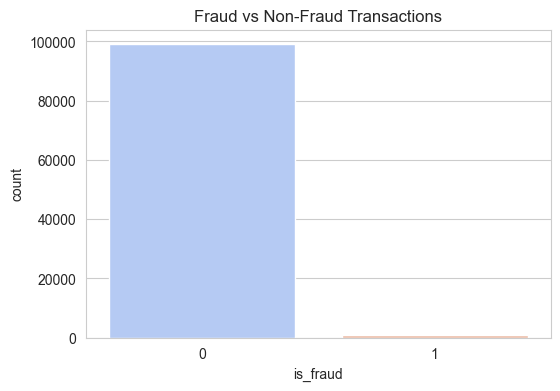

In [15]:
# Fraud vs Non-Fraud Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='is_fraud', data=df, palette='coolwarm')
plt.title('Fraud vs Non-Fraud Transactions')
plt.savefig('../images/fraud_distribution.png', bbox_inches='tight')
plt.show()

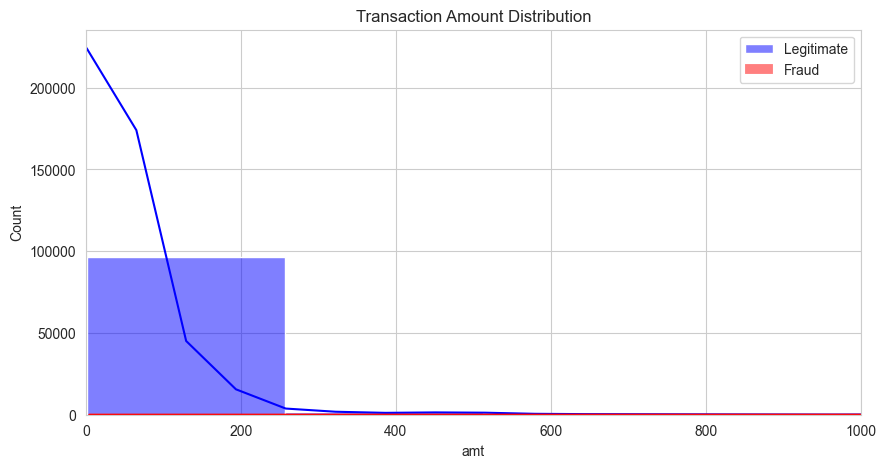

In [16]:
# Transaction Amount Analysis
plt.figure(figsize=(10,5))
sns.histplot(df[df['is_fraud']==0]['amt'], bins=50, color='blue', kde=True, label='Legitimate')
sns.histplot(df[df['is_fraud']==1]['amt'], bins=50, color='red', kde=True, label='Fraud')
plt.title('Transaction Amount Distribution')
plt.xlim(0, 1000)
plt.legend()
plt.savefig('../images/amt_distribution.png', bbox_inches='tight')
plt.show()

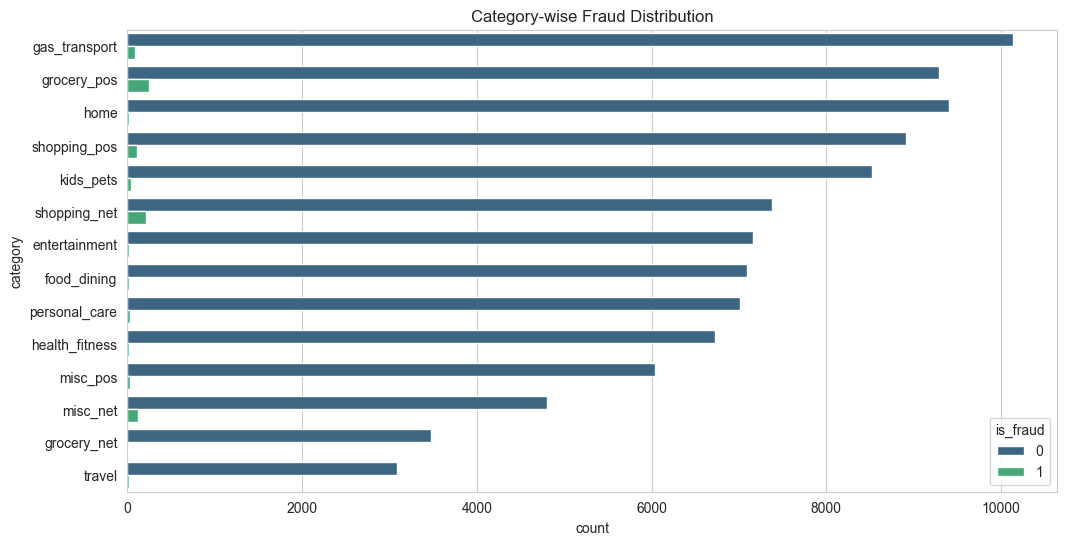

In [17]:
# Category-wise Fraud Analysis
plt.figure(figsize=(12,6))
sns.countplot(y='category', hue='is_fraud', data=df, palette='viridis', order=df['category'].value_counts().index)
plt.title('Category-wise Fraud Distribution')
plt.savefig('../images/category_fraud.png', bbox_inches='tight')
plt.show()

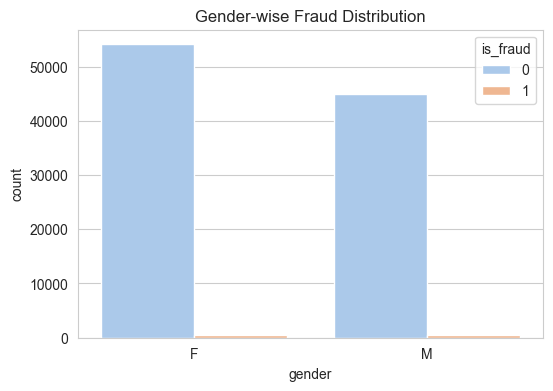

In [18]:
if 'gender' in df.columns:
    # Gender-wise Fraud Analysis
    plt.figure(figsize=(6,4))
    sns.countplot(x='gender', hue='is_fraud', data=df, palette='pastel')
    plt.title('Gender-wise Fraud Distribution')
    plt.savefig('../images/gender_fraud.png', bbox_inches='tight')
    plt.show()

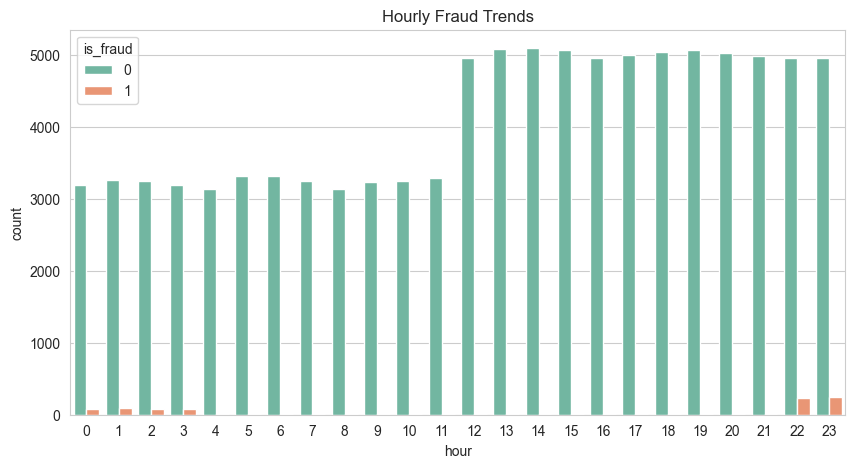

In [19]:
if 'hour' in df.columns:
    # Time-based Fraud Trends (Hourly)
    plt.figure(figsize=(10,5))
    sns.countplot(x='hour', hue='is_fraud', data=df, palette='Set2')
    plt.title('Hourly Fraud Trends')
    plt.savefig('../images/hourly_fraud.png', bbox_inches='tight')
    plt.show()

## 4. Encoding and Splitting Data

In [20]:
# Encoding categorical features
categorical_cols = df.select_dtypes(include=['object']).columns

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Splitting the data
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

# Scaling numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (80000, 7)
Testing data shape: (20000, 7)


## 5. Model Training & Evaluation

Training Logistic Regression...
Logistic Regression - Accuracy: 0.9893, Precision: 0.0000, Recall: 0.0000, F1: 0.0000, ROC-AUC: 0.8429


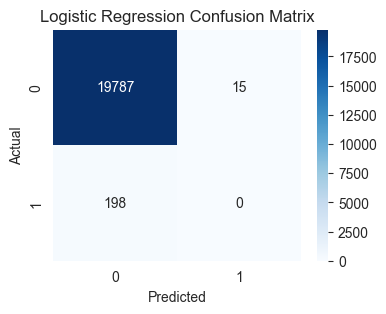

--------------------------------------------------
Training Decision Tree...
Decision Tree - Accuracy: 0.9945, Precision: 0.7056, Recall: 0.7626, F1: 0.7330, ROC-AUC: 0.8797


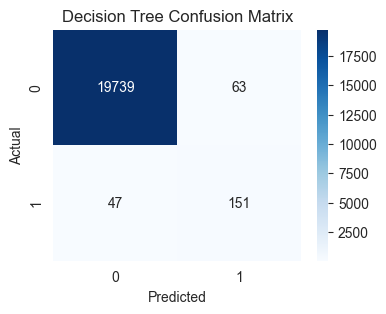

--------------------------------------------------
Training Random Forest...
Random Forest - Accuracy: 0.9963, Precision: 0.8924, Recall: 0.7121, F1: 0.7921, ROC-AUC: 0.9707


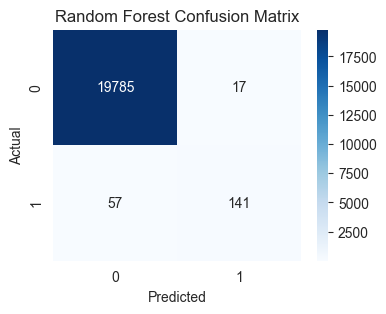

--------------------------------------------------


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.98935,0.000000,0.000000,0.000000,0.842900
1,Decision Tree,0.99450,0.705607,0.762626,0.733010,0.879722
2,Random Forest,0.99630,0.892405,0.712121,0.792135,0.970699


In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else [0]*len(y_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else 0
    
    results.append([name, acc, prec, rec, f1, roc_auc])
    trained_models[name] = model
    
    print(f"{name} - Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}, ROC-AUC: {roc_auc:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.savefig(f'../images/{name.replace(" ", "_")}_cm.png', bbox_inches='tight')
    plt.show()
    print("-"*50)

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'])
display(results_df)

## 6. Select Best Model and Save

In [22]:
best_model_name = results_df.sort_values(by='ROC-AUC', ascending=False).iloc[0]['Model']
print(f"Best Model based on ROC-AUC: {best_model_name}")
best_model = trained_models[best_model_name]

# Save the model
model_path = '../model/fraud_model.pkl'
with open(model_path, 'wb') as file:
    pickle.dump(best_model, file)
print(f"Model successfully saved to {model_path}")

Best Model based on ROC-AUC: Random Forest
Model successfully saved to ../model/fraud_model.pkl
